# Taxonomic Orchid Dataset Summary

This notebook scans the Taxonomic Orchid dataset folder and reports:

- number of genera
- number of species
- total number of images
- minimum, median, and maximum images per species
- per-genus species counts
- per-species image counts
- plots that show the image-count distribution and class imbalance

It assumes the dataset follows this structure:

```text
TaxonomicOrchidDataset/
  Genus/
    Species/
      image1.jpg
      image2.jpg
```

Folders named `UNLABELED` are ignored.

In [3]:
from pathlib import Path
from statistics import median

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

DATASET_ROOT = Path(r"/datasets/taxonomic-orchid")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

sns.set_theme(style="whitegrid", context="talk")
DATASET_ROOT

PosixPath('/datasets/taxonomic-orchid')

In [4]:
def is_image_file(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS


def collect_dataset_stats(dataset_root: Path):
    if not dataset_root.exists():
        raise FileNotFoundError(f"Dataset path does not exist: {dataset_root}")

    records = []

    for genus_path in sorted(dataset_root.iterdir()):
        if not genus_path.is_dir() or genus_path.name.upper() == "UNLABELED":
            continue

        for species_path in sorted(genus_path.iterdir()):
            if not species_path.is_dir() or species_path.name.upper() == "UNLABELED":
                continue

            image_count = sum(1 for path in species_path.rglob("*") if is_image_file(path))
            records.append(
                {
                    "genus": genus_path.name,
                    "species": species_path.name,
                    "image_count": image_count,
                }
            )

    species_df = pd.DataFrame(records).sort_values(["genus", "species"]).reset_index(drop=True)

    if species_df.empty:
        raise ValueError("No species folders with images were found in the dataset.")

    genus_df = (
        species_df.groupby("genus", as_index=False)
        .agg(species_count=("species", "count"), total_images=("image_count", "sum"))
        .sort_values(["species_count", "total_images", "genus"], ascending=[False, False, True])
        .reset_index(drop=True)
    )

    image_counts = species_df["image_count"]
    summary = {
        "num_genera": int(species_df["genus"].nunique()),
        "num_species": int(len(species_df)),
        "total_images": int(image_counts.sum()),
        "min_images_per_species": int(image_counts.min()),
        "q1_images_per_species": float(image_counts.quantile(0.25)),
        "median_images_per_species": float(median(image_counts.tolist())),
        "q3_images_per_species": float(image_counts.quantile(0.75)),
        "max_images_per_species": int(image_counts.max()),
        "mean_images_per_species": float(image_counts.mean()),
        "species_with_zero_images": int((image_counts == 0).sum()),
        "species_below_50_images": int((image_counts < 50).sum()),
        "species_below_100_images": int((image_counts < 100).sum()),
    }

    return species_df, genus_df, summary


species_df, genus_df, summary = collect_dataset_stats(DATASET_ROOT)
summary

{'num_genera': 64,
 'num_species': 202,
 'total_images': 50517,
 'min_images_per_species': 0,
 'q1_images_per_species': 47.5,
 'median_images_per_species': 229.0,
 'q3_images_per_species': 361.25,
 'max_images_per_species': 1027,
 'mean_images_per_species': 250.08415841584159,
 'species_with_zero_images': 2,
 'species_below_50_images': 52,
 'species_below_100_images': 61}

In [5]:
summary_df = pd.DataFrame(
    [
        ("Genera", summary["num_genera"]),
        ("Species", summary["num_species"]),
        ("Total images", summary["total_images"]),
        ("Minimum images per species", summary["min_images_per_species"]),
        ("25th percentile images per species", summary["q1_images_per_species"]),
        ("Median images per species", summary["median_images_per_species"]),
        ("75th percentile images per species", summary["q3_images_per_species"]),
        ("Maximum images per species", summary["max_images_per_species"]),
        ("Mean images per species", round(summary["mean_images_per_species"], 2)),
        ("Species with zero images", summary["species_with_zero_images"]),
        ("Species with fewer than 50 images", summary["species_below_50_images"]),
        ("Species with fewer than 100 images", summary["species_below_100_images"]),
    ],
    columns=["metric", "value"],
)

summary_df

,metric,value
0,Genera,64.00
1,Species,202.00
2,Total images,50517.00
3,Minimum images per species,0.00
4,25th percentile images per species,47.50
5,Median images per species,229.00
6,75th percentile images per species,361.25
7,Maximum images per species,1027.00
8,Mean images per species,250.08
9,Species with zero images,2.00


In [6]:
discussion = f"""
## Discussion

The dataset contains **{summary['num_genera']} genera** and **{summary['num_species']} species**.
Across all species folders, there are **{summary['total_images']} images** in total.

The per-species image distribution ranges from **{summary['min_images_per_species']}** images in the smallest species folder
to **{summary['max_images_per_species']}** images in the largest one, with a **median of {summary['median_images_per_species']}** images per species.
The middle 50% of species fall between **{summary['q1_images_per_species']}** and **{summary['q3_images_per_species']}** images.

This is useful for diagnosing class imbalance. If the minimum is near zero while the maximum is much larger,
the dataset is likely skewed and may benefit from reweighting, augmentation, oversampling, or targeted data collection.
The counts for species with fewer than 50 or 100 images also provide a practical estimate of how many classes may be underrepresented.
"""

display(Markdown(discussion))


## Discussion

The dataset contains **64 genera** and **202 species**.
Across all species folders, there are **50517 images** in total.

The per-species image distribution ranges from **0** images in the smallest species folder
to **1027** images in the largest one, with a **median of 229.0** images per species.
The middle 50% of species fall between **47.5** and **361.25** images.

This is useful for diagnosing class imbalance. If the minimum is near zero while the maximum is much larger,
the dataset is likely skewed and may benefit from reweighting, augmentation, oversampling, or targeted data collection.
The counts for species with fewer than 50 or 100 images also provide a practical estimate of how many classes may be underrepresented.


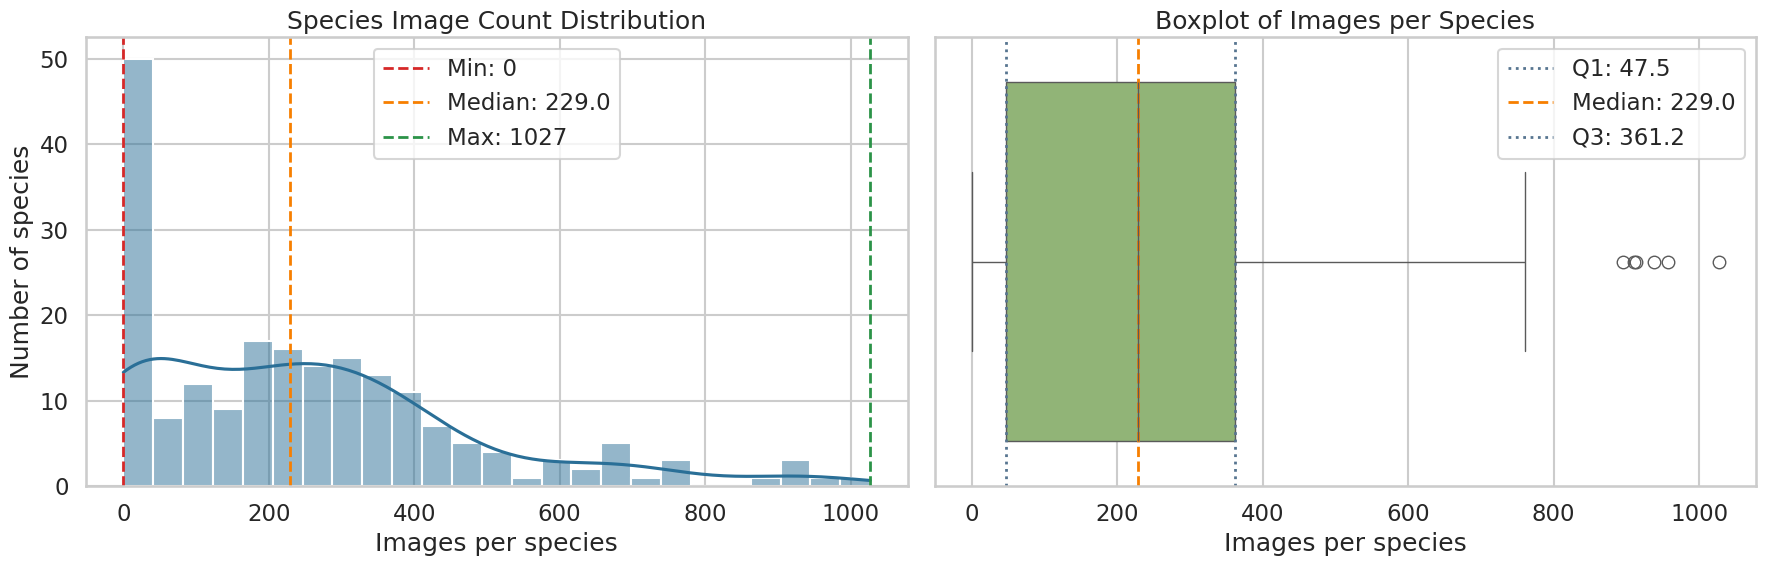

In [7]:
image_counts = species_df["image_count"]
min_count = summary["min_images_per_species"]
median_count = summary["median_images_per_species"]
max_count = summary["max_images_per_species"]
q1_count = summary["q1_images_per_species"]
q3_count = summary["q3_images_per_species"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(image_counts, bins=25, kde=True, ax=axes[0], color="#2a6f97")
axes[0].axvline(min_count, color="#d62828", linestyle="--", linewidth=2, label=f"Min: {min_count}")
axes[0].axvline(median_count, color="#f77f00", linestyle="--", linewidth=2, label=f"Median: {median_count}")
axes[0].axvline(max_count, color="#2b9348", linestyle="--", linewidth=2, label=f"Max: {max_count}")
axes[0].set_title("Species Image Count Distribution")
axes[0].set_xlabel("Images per species")
axes[0].set_ylabel("Number of species")
axes[0].legend()

sns.boxplot(x=image_counts, ax=axes[1], color="#90be6d")
axes[1].axvline(q1_count, color="#577590", linestyle=":", linewidth=2, label=f"Q1: {q1_count:.1f}")
axes[1].axvline(median_count, color="#f77f00", linestyle="--", linewidth=2, label=f"Median: {median_count}")
axes[1].axvline(q3_count, color="#577590", linestyle=":", linewidth=2, label=f"Q3: {q3_count:.1f}")
axes[1].set_title("Boxplot of Images per Species")
axes[1].set_xlabel("Images per species")
axes[1].legend()

plt.tight_layout()
plt.show()

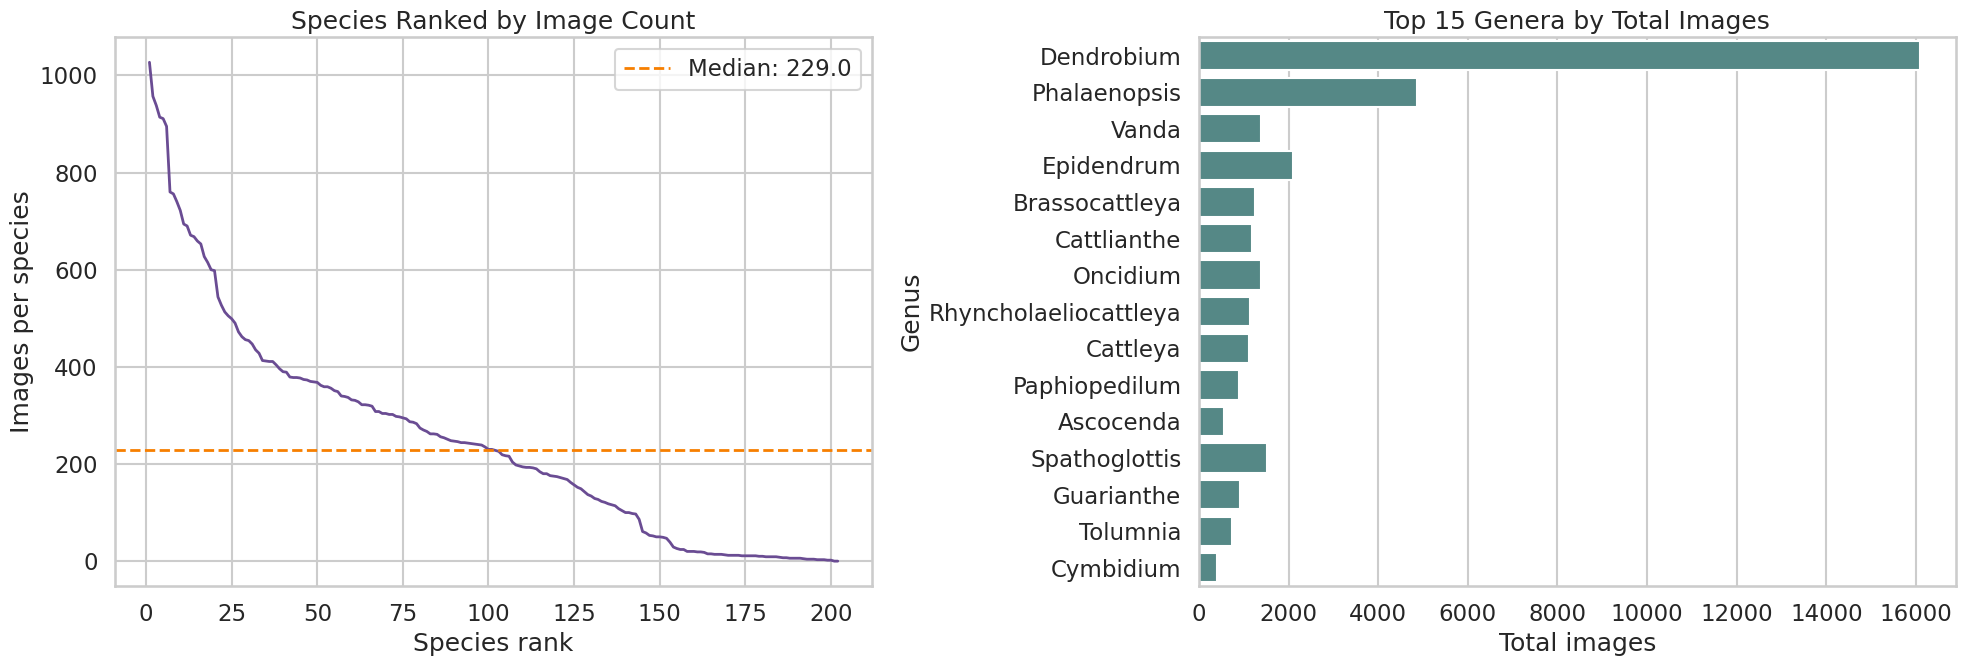

In [8]:
sorted_species_df = species_df.sort_values("image_count", ascending=False).reset_index(drop=True)
top_15_genera = genus_df.head(15)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

axes[0].plot(sorted_species_df.index + 1, sorted_species_df["image_count"], color="#6a4c93", linewidth=2)
axes[0].axhline(median_count, color="#f77f00", linestyle="--", linewidth=2, label=f"Median: {median_count}")
axes[0].set_title("Species Ranked by Image Count")
axes[0].set_xlabel("Species rank")
axes[0].set_ylabel("Images per species")
axes[0].legend()

sns.barplot(data=top_15_genera, y="genus", x="total_images", ax=axes[1], color="#4d908e")
axes[1].set_title("Top 15 Genera by Total Images")
axes[1].set_xlabel("Total images")
axes[1].set_ylabel("Genus")

plt.tight_layout()
plt.show()

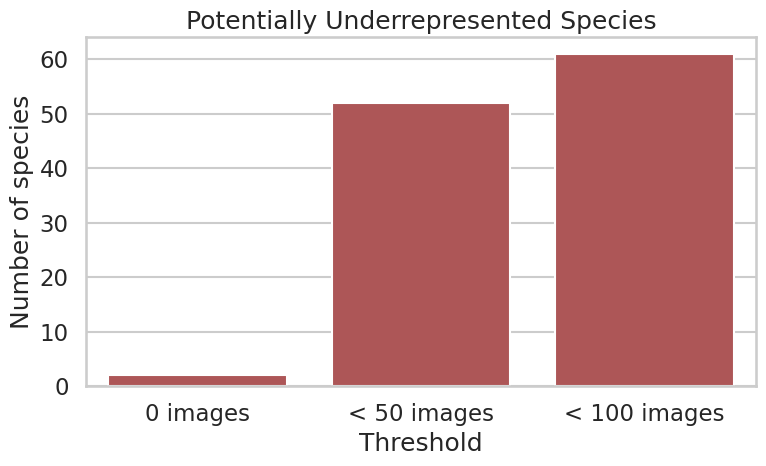

,threshold,species_count
0,0 images,2
1,< 50 images,52
2,< 100 images,61


In [9]:
threshold_summary = pd.DataFrame(
    {
        "threshold": ["0 images", "< 50 images", "< 100 images"],
        "species_count": [
            summary["species_with_zero_images"],
            summary["species_below_50_images"],
            summary["species_below_100_images"],
        ],
    }
)

plt.figure(figsize=(8, 5))
sns.barplot(data=threshold_summary, x="threshold", y="species_count", color="#bc4749")
plt.title("Potentially Underrepresented Species")
plt.xlabel("Threshold")
plt.ylabel("Number of species")
plt.tight_layout()
plt.show()

threshold_summary

In [10]:
genus_df

,genus,species_count,total_images
0,Dendrobium,60,16085
1,Phalaenopsis,23,4865
2,Vanda,10,1377
3,Epidendrum,6,2110
4,Brassocattleya,6,1248
...,...,...,...
59,Cirrhopetalum,1,9
60,Coelogyne,1,9
61,Caulaelia,1,8
62,Perreiraara,1,6


In [11]:
species_df

,genus,species,image_count
0,Arachnis,Arach. Maggie Oei 'Red Ribbon',86
1,Arachnis,Arach. flos-aeris,29
2,Arachnostylis,Arach. Jittima 'Red',544
3,Arachnostylis,Arach. Jittima 'White Spot',322
4,Aranthera,Arnth. Anne Black,240
...,...,...,...
197,Vanda,V. Thailand Gold x Kulwadee Fragrance,50
198,Vanda,V. Warintra Pink,298
199,Vanda,V. aurantiacum,15
200,Vanda,Vanda M.V. Tannins 'Kirk' AM AOS,108


In [12]:
top_10_species = species_df.sort_values(["image_count", "genus", "species"], ascending=[False, True, True]).head(10)
bottom_10_species = species_df.sort_values(["image_count", "genus", "species"], ascending=[True, True, True]).head(10)

display(Markdown("## Top 10 species by image count"))
display(top_10_species)

display(Markdown("## Bottom 10 species by image count"))
display(bottom_10_species)

## Top 10 species by image count

,genus,species,image_count
57,Dendrobium,Den. Frosty Dawn,1027
115,Epidendrum,Epi. secundum violet,957
111,Epidendrum,Epi. cinnabarinum,938
91,Dendrobium,Den. anosmum,914
100,Dendrobium,Den. crumenatum 'Pigeon Orchid',911
101,Dendrobium,Den. friedericksianum,895
183,Spathoglottis,Spa. plicata,760
129,Ludisia,Lus. discolor,756
162,Phalaenopsis,Phal. Sogo Yukidian,740
174,Psychilis,Psy. krugii,722


## Bottom 10 species by image count

,genus,species,image_count
6,Ascocenda,Ascda,0
61,Dendrobium,Den. Haleahi Hearthrod x Den. Jacquelyn Thomas,0
94,Dendrobium,Den. aphyllum,2
96,Dendrobium,Den. bracteosum var. tanii,2
30,Cattleya,C. skinneri var. alba,3
47,Dendrobium,Den. Brown,3
196,Vanda,V. Thailand Gold 'Kao',3
48,Dendrobium,Den. Bunara Pink,4
133,Miltoniopsis,Mps. Molten Lava,4
192,Vanda,V. Huifen Chan,4
